# Results of CaSR Wind 

Outputs of `CaSR` winds (`u`,`v`) may explain why `00mar23` run blew up.

## Surface Velocity (in the north)

In [3]:
# path

path_u_CaSR='/ocean/jqiu/results/CaSR/01mar23_CaSR_wind_only/SalishSea_1h_20230301_20230301_grid_U.nc'
path_v_CaSR='/ocean/jqiu/results/CaSR/01mar23_CaSR_wind_only/SalishSea_1h_20230301_20230301_grid_V.nc'

path_u_HRDPS='/results2/SalishSea/nowcast-green.202111/01mar23/SalishSea_1h_20230301_20230301_grid_U.nc'
path_v_HRDPS='/results2/SalishSea/nowcast-green.202111/01mar23/SalishSea_1h_20230301_20230301_grid_V.nc'

# extract data

import xarray as xr
import numpy as np

ds_u_CaSR = xr.open_dataset(path_u_CaSR)
ds_v_CaSR = xr.open_dataset(path_v_CaSR)

ds_u_HRDPS = xr.open_dataset(path_u_HRDPS)
ds_v_HRDPS = xr.open_dataset(path_v_HRDPS)

# calculate the surface speed

u_CaSR = ds_u_CaSR['vozocrtx'].isel(depthu=0).values
v_CaSR = ds_v_CaSR['vomecrty'].isel(depthv=0).values

u_HRDPS = ds_u_HRDPS['vozocrtx'].isel(depthu=0).values
v_HRDPS = ds_v_HRDPS['vomecrty'].isel(depthv=0).values

velocity_CaSR=np.sqrt(u_CaSR**2+v_CaSR**2)
velocity_HRDPS=np.sqrt(u_HRDPS**2+v_HRDPS**2)


# the velocity in the north
u_point_CaSR=u_CaSR[:,867,70]
v_point_CaSR=v_CaSR[:,867,70]
u_point_HRDPS=u_HRDPS[:,867,70]
v_point_HRDPS=v_HRDPS[:,867,70]
velocity_point_CaSR=velocity_CaSR[:,867,70]
velocity_point_HRDPS=velocity_HRDPS[:,867,70]


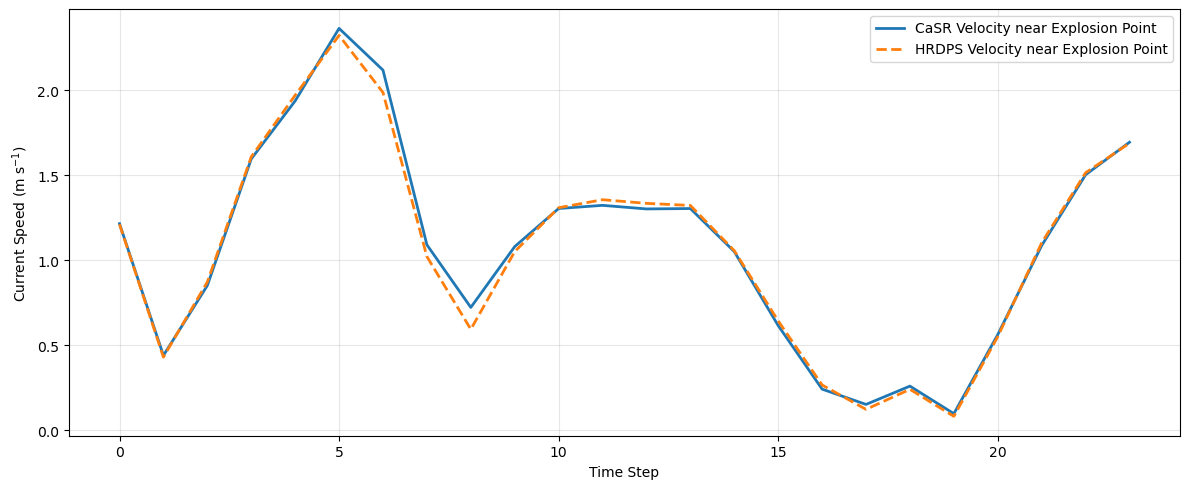

In [4]:
# visualize velocity


import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(velocity_point_CaSR,
    label='CaSR Velocity near Explosion Point',
    linewidth=2
)

ax.plot(velocity_point_HRDPS,
    label='HRDPS Velocity near Explosion Point',
    linestyle='--',
    linewidth=2
)


ax.set_xlabel('Time Step')
ax.set_ylabel('Current Speed (m s$^{-1}$)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Compare the results with the all `CaSR` forcing field from `mar23_CaSRvs_HRDPS.ipynb`.

See https://github.com/SalishSeaCast/analysis-junqi/blob/main/Analysis_Atmospheric_Forcing/Analysis_results_comparison/Test_results_comparison/mar23_CaSRvs_HRDPS.ipynb

The accuracy is **much higher**.

## SST

Also take a look at sea surface temperature.

In [5]:
# SST between HRDPS outputs vs CaSR outputs

# path

path_CaSR_t='/ocean/jqiu/results/CaSR/01mar23_CaSR_wind_only/SalishSea_1h_20230301_20230301_grid_T.nc'

path_HRDPS_t='/results2/SalishSea/nowcast-green.202111/01mar23/SalishSea_1h_20230301_20230301_grid_T.nc'




# load data

import xarray as xr

ds_CaSR_t=xr.open_dataset(path_CaSR_t)


ds_HRDPS_t=xr.open_dataset(path_HRDPS_t)



# calculate the surface speed

t_CaSR = ds_CaSR_t['votemper'].isel(deptht=0).values


t_HRDPS = ds_HRDPS_t['votemper'].isel(deptht=0).values




import numpy as np



t_point_CaSR=t_CaSR[:,867,70]
t_point_HRDPS=t_HRDPS[:,867,70]



<>:22: SyntaxWarning: invalid escape sequence '\c'
<>:22: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_1803846/1298158312.py:22: SyntaxWarning: invalid escape sequence '\c'
  ax.set_ylabel('Temperature ($^{\circ}$C)')


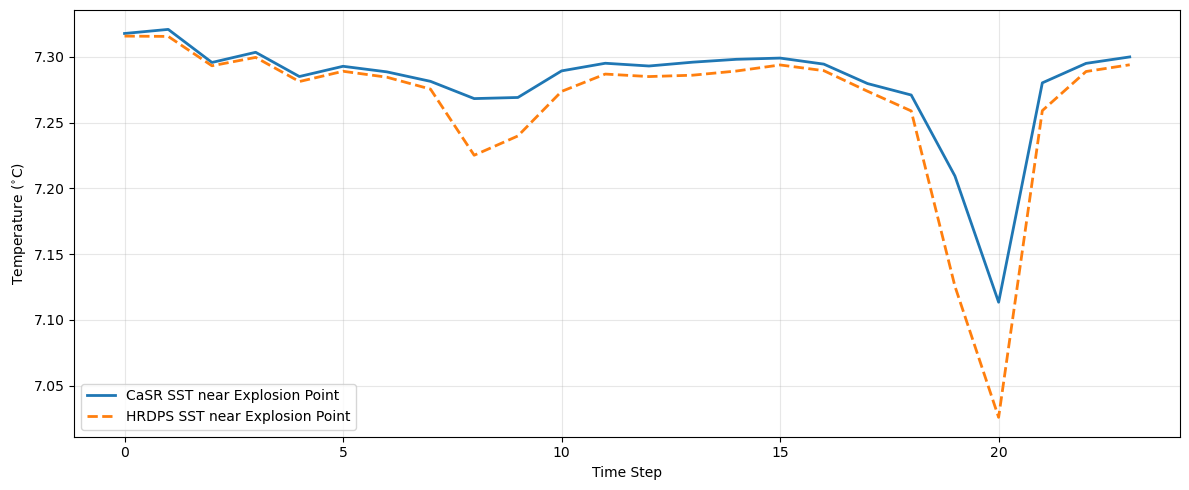

In [6]:
# visualize SST

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(t_point_CaSR,
    label='CaSR SST near Explosion Point',
    linewidth=2
)

ax.plot(t_point_HRDPS,
    label='HRDPS SST near Explosion Point',
    linestyle='--',
    linewidth=2
)




ax.set_xlabel('Time Step')
ax.set_ylabel('Temperature ($^{\circ}$C)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


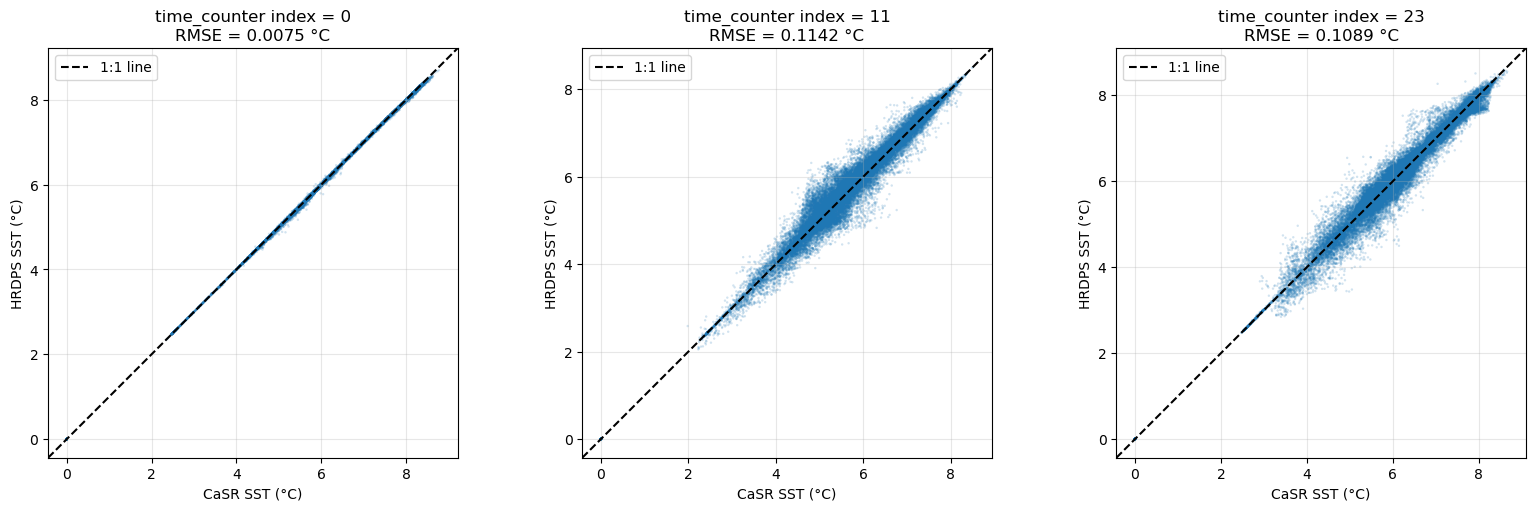

SST RMSE results:
time_counter index 0: RMSE = 0.0075 °C
time_counter index 11: RMSE = 0.1142 °C
time_counter index 23: RMSE = 0.1089 °C


In [7]:
# scatter plot for SST

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt


path_CaSR = (
    "/ocean/jqiu/results/CaSR/01mar23_CaSR_wind_only/"
    "SalishSea_1h_20230301_20230301_grid_T.nc"
)

path_HRDPS = (
    "/results2/SalishSea/nowcast-green.202111/01mar23/"
    "SalishSea_1h_20230301_20230301_grid_T.nc"
)

vname_temp = "votemper"
vname_depth = "deptht"


# 读取温度数据
ds_CaSR = xr.open_dataset(path_CaSR)
ds_HRDPS = xr.open_dataset(path_HRDPS)

# 取最表层海水温度
SST_CaSR = ds_CaSR[vname_temp].isel({vname_depth: 0}).squeeze(drop=True)
SST_HRDPS = ds_HRDPS[vname_temp].isel({vname_depth: 0}).squeeze(drop=True)


# 要比较的时间索引
time_indices = [0, 11, 23]

fig, axes = plt.subplots(
    1,
    len(time_indices),
    figsize=(16, 5),
    constrained_layout=True
)

rmse_results = {}

for ax, time_idx in zip(axes, time_indices):

    # 提取对应时间步，并转成一维数组
    casr = SST_CaSR.isel(time_counter=time_idx).values.ravel()
    hrdps = SST_HRDPS.isel(time_counter=time_idx).values.ravel()

    # 只保留两个数据均为有限值的位置
    valid = np.isfinite(casr) & np.isfinite(hrdps)
    casr_valid = casr[valid]
    hrdps_valid = hrdps[valid]

    if casr_valid.size == 0:
        raise ValueError(
            f"time_counter index={time_idx} 没有共同的有效温度数据。"
        )

    # 计算 RMSE：以 CaSR 为参考
    rmse = np.sqrt(
        np.mean((hrdps_valid - casr_valid) ** 2)
    )
    rmse_results[time_idx] = rmse

    # 散点图
    ax.scatter(
        casr_valid,
        hrdps_valid,
        s=3,
        alpha=0.2,
        edgecolors="none"
    )

    # 根据该时刻两个温度场共同确定坐标范围
    lower = min(
        np.nanmin(casr_valid),
        np.nanmin(hrdps_valid)
    )

    upper = max(
        np.nanmax(casr_valid),
        np.nanmax(hrdps_valid)
    )

    # 在上下限两端稍微留一些空间
    padding = 0.05 * (upper - lower)

    if padding == 0:
        padding = 0.5

    lower -= padding
    upper += padding

    # 添加 1:1 参考线
    ax.plot(
        [lower, upper],
        [lower, upper],
        linestyle="--",
        linewidth=1.5,
        color="k",
        label="1:1 line"
    )

    ax.set_xlim(lower, upper)
    ax.set_ylim(lower, upper)
    ax.set_aspect("equal", adjustable="box")

    ax.set_xlabel("CaSR SST (°C)")
    ax.set_ylabel("HRDPS SST (°C)")

    ax.set_title(
        f"time_counter index = {time_idx}\n"
        f"RMSE = {rmse:.4f} °C"
    )

    ax.grid(alpha=0.3)
    ax.legend()

plt.show()

print("SST RMSE results:")
for time_idx, rmse in rmse_results.items():
    print(f"time_counter index {time_idx}: RMSE = {rmse:.4f} °C")

ds_CaSR.close()
ds_HRDPS.close()